In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv(
    "../data/processed/featured_uhi_v2.csv"
)

df.head()

,Elevation,LST,Latitude,Longitude,NDBI,NDVI,Population,Green_Built_Ratio,Population_Heat_Index,Elevation_Cooling_Index
0,919,43.919170,19.970832,75.438700,0.127207,0.162286,1.562392,1.182783,0.198747,149.140825
1,488,39.060455,19.729093,75.209548,-0.272423,0.570751,1.361367,2.020910,-0.370867,278.526341
2,505,40.231127,19.788775,75.225639,0.055877,0.099371,15.386780,1.508423,0.859774,50.182390
3,757,44.884761,19.960297,75.544582,0.121404,0.196037,2.643492,1.491866,0.320931,148.400233
4,586,48.502735,19.867709,75.486062,0.133151,0.165262,31.397209,1.154459,4.180581,96.843708


In [24]:
X = df[
    [
        "NDVI",
        "NDBI",
        "Elevation",
        "Population",
        "Latitude",
        "Longitude"
    ]
]

y = df["LST"]

print(X.shape)
print(X.columns)

(9893, 6)
Index(['NDVI', 'NDBI', 'Elevation', 'Population', 'Latitude', 'Longitude'], dtype='str')


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest V2 Trained")

Random Forest V2 Trained


In [27]:
predictions = rf_model.predict(
    X_test
)

In [28]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2 :", r2)

MAE : 1.4617172921655877
RMSE: 1.8651401715336104
R2 : 0.6798811484597254


In [30]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,43.003141,42.944180
1,41.793162,41.470945
2,42.148636,38.832832
3,43.042448,42.557807
4,47.738808,46.099366
5,44.818110,43.145410
6,44.696770,43.789183
7,45.153076,42.252213
8,41.733347,39.877390
9,46.968044,46.894933


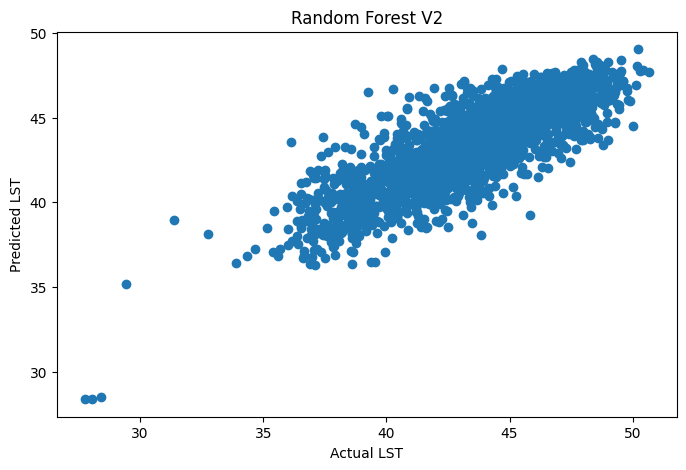

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("Random Forest V2")

plt.show()